# Fingerprint Embedding Network — (9, 33, 384) tensors

Speaker verification on STDP weight fingerprints (reduced 4-neuron architecture). Each
sample is stored **compact** and expanded to the model input `(9, 33, 384)` **at model
time**:

| channels | source | meaning |
|---|---|---|
| `0:4` | `weights (4,33,384)` | STDP weight type-images (4 input-neuron types) |
| `4:8` | `input_activity (384,)` gathered via `IN_IDX` | presynaptic input firing rate, co-registered |
| `8:9` | `hidden_activity (384,)` broadcast over offset | hidden firing rate |

over a `33` tonotopic-offset (−16..+16) × `384` hidden-neuron plane.

**Architecture**: input BatchNorm → 2D ResNet (downsamples the 384 hidden axis hard, the
33 offset axis gently) → attentive statistics pooling → ArcFace (AAM-Softmax). Trained on
the 1211 dev speakers; evaluated **open-set** on the 40 disjoint test speakers
(test-internal verification: EER, Rank-1/5, mAP via cosine).

### Ablation selector — `FINGERPRINT_MODE`
Set in the config cell, one value per upload:
- **`"full"` (A)** — all 9 channels.
- **`"rates_only"` (B)** — weight channels neutralised; the 5 rate channels kept.
- **`"weights_only"` (C)** — the 5 rate channels neutralised; weight channels kept.

Ablated channels are replaced by a zero-variance constant (`exp(-30)`, neutralised by the
input BatchNorm), so the architecture and parameter count are **identical across modes** —
only the available input information changes. Compare best EER across the three runs to see
how much the weights vs. the firing rates each contribute.

Run all cells top-to-bottom. Requires torch, numpy, scikit-learn, matplotlib. No brian2
or repo dependency — `IN_IDX` is recomputed inline.

In [1]:
import os, sys, glob, random, math
from collections import defaultdict
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import SGD
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ══════════════════════════════════════════════════════════════════════════════
#  THE ABLATION SELECTOR  —  set this per upload
# ══════════════════════════════════════════════════════════════════════════════
FINGERPRINT_MODE = "full"   # one of:
#   "full"          A — all 9 channels (4 weight + 4 input-rate + 1 hidden-rate)
#   "rates_only"    B — weight channels neutralised; rate channels kept
#   "weights_only"  C — rate channels neutralised; weight channels kept
assert FINGERPRINT_MODE in ("full", "rates_only", "weights_only")

# ── Compute ───────────────────────────────────────────────────────────────────
USE_DATAPARALLEL = True        # use both T4s if present (auto-falls back to 1 GPU)
USE_AMP          = True        # fp16 autocast + GradScaler

# ── Paths ─────────────────────────────────────────────────────────────────────
# Point INPUT_DIR at the uploaded dataset dir holding the *_fingerprints_*.npz shards.
INPUT_DIR  = "/kaggle/input/datasets/qphulong/vox1-all-person-all-session-2-samples-per-session"
WORK_DIR   = "/kaggle/working"
DEV_GLOB   = os.path.join(INPUT_DIR, "dev_fingerprints_*.npz")
TEST_GLOB  = os.path.join(INPUT_DIR, "test_fingerprints_*.npz")

MODE_TAG   = FINGERPRINT_MODE
CHECKPOINT = os.path.join(WORK_DIR, f"best_model_{MODE_TAG}.pth")

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_GPU    = torch.cuda.device_count()
print("Device:", DEVICE, "| GPUs:", N_GPU)
if torch.cuda.is_available():
    for i in range(N_GPU):
        print(f"  GPU{i}:", torch.cuda.get_device_name(i))

# ── Input geometry  (compact → model input (9,33,384) at model time) ──────────
N_CHANNELS    = 96       # tonotopic auditory channels
N_PER_CHANNEL = 4        # input neurons / channel  (2 sustained, 1 onset, 1 phase)
N_H           = 384      # hidden neurons  = last axis of every tensor
R_OFF         = 16       # tonotopic offset radius → 33 offsets
IN_CH = 9                # 4 weight + 4 input-rate + 1 hidden-rate
H_OFF = 2 * R_OFF + 1    # 33
W_HID = N_H              # 384
NEUTRAL_FILL = math.exp(-30)   # zero-variance constant for ablated channels (≈9.4e-14)

# ── IN_IDX  (identical to _fingerprint_core.py) ───────────────────────────────
# IN_IDX[t,o,j] = ((ch_j + offset_o) % 96) * 4 + t  → index into the 384 input axis,
# so input_activity[IN_IDX] co-registers the presynaptic rate with the weight tensor.
OFFSETS = np.arange(-R_OFF, R_OFF + 1)                               # (33,)
_ch_j   = np.arange(N_H) // N_PER_CHANNEL                            # (384,)
_in_ch  = (_ch_j[None, :] + OFFSETS[:, None]) % N_CHANNELS           # (33, 384)
IN_IDX  = np.stack([_in_ch * N_PER_CHANNEL + t for t in range(N_PER_CHANNEL)])  # (4,33,384)
IN_IDX_T = torch.as_tensor(IN_IDX, dtype=torch.long, device=DEVICE)

# ── Augmentation ──────────────────────────────────────────────────────────────
ROLL_MAX_CH = 2          # max tonotopic jitter (channels); small = mild mic-response invariance

# ── Hyperparameters ───────────────────────────────────────────────────────────
EMBED_DIM    = 256
M            = 0.2       # ArcFace target margin (ramped in — see MARGIN_WARMUP_EPOCHS)
S            = 30        # ArcFace scale
LR           = 0.08      # peak LR (after warmup)
WEIGHT_DECAY = 5e-4
EPOCHS       = 30        # Tier 1: ↓ from 80 — best EER lands by ~ep15-25, rest was collapse
WARMUP_EPOCHS        = 3    # linear LR warmup, then cosine
MARGIN_WARMUP_EPOCHS = 15   # ramp ArcFace margin 0→M (prevents early angular-margin collapse)
EARLY_STOP_PATIENCE  = 8    # Tier 1: stop if val EER hasn't improved for this many epochs
GRAD_CLIP            = 5.0  # max grad-norm (0 disables)
P_CLASSES    = 32        # classes per PK batch
K_SAMPLES    = 4         # samples per class → batch size = 128

torch.manual_seed(42); np.random.seed(42); random.seed(42)
print(f"\n{'='*60}\n  FINGERPRINT_MODE: {FINGERPRINT_MODE}\n{'='*60}")
print(f"Input {IN_CH}x{H_OFF}x{W_HID}  | DataParallel={USE_DATAPARALLEL and N_GPU>1} | AMP={USE_AMP}")

Device: cuda | GPUs: 2
  GPU0: Tesla T4
  GPU1: Tesla T4

  FINGERPRINT_MODE: full
Input 9x33x384  | DataParallel=True | AMP=True


In [2]:
def load_split(glob_pattern):
    """Concatenate all matching shards → compact arrays (preallocated, no 2x peak).

    Returns weights (N,4,33,384) f16, input_activity (N,384) f16,
    hidden_activity (N,384) f16, person_ids (N,), record_ids (N,).
    """
    paths = sorted(glob.glob(glob_pattern))
    if not paths:
        raise FileNotFoundError(f"no shards match: {glob_pattern}")
    sizes = []
    for p in paths:
        with np.load(p, allow_pickle=True) as d:
            sizes.append(len(d["labels"]))
    N = sum(sizes)
    W  = np.empty((N, N_PER_CHANNEL, H_OFF, W_HID), np.float16)
    IA = np.empty((N, N_H), np.float16)
    HA = np.empty((N, N_H), np.float16)
    pids, recs, off = [], [], 0
    for p, n in zip(paths, sizes):
        with np.load(p, allow_pickle=True) as d:
            W[off:off+n]  = d["weights"]
            IA[off:off+n] = d["input_activity"]
            HA[off:off+n] = d["hidden_activity"]
            pids.append(d["person_ids"]); recs.append(d["record_ids"])
            off += n
    print(f"  {os.path.basename(glob_pattern)}: {len(paths)} shard(s) → {N} samples")
    return W, IA, HA, np.concatenate(pids), np.concatenate(recs)

print("Loading dev ...");  Wd, IAd, HAd, pid_train, rec_train = load_split(DEV_GLOB)
print("Loading test ..."); Wt, IAt, HAt, pid_val,   rec_val   = load_split(TEST_GLOB)

# Train labels = dev speakers (closed-set classification target).
all_persons     = sorted(set(pid_train.tolist()))
NUM_CLASSES     = len(all_persons)
person_to_label = {p: i for i, p in enumerate(all_persons)}
y_train = np.array([person_to_label[p] for p in pid_train], dtype=np.int64)

# Test speakers are DISJOINT (open set) → own label space for same/diff pairing only.
val_persons  = sorted(set(pid_val.tolist()))
val_to_label = {p: i for i, p in enumerate(val_persons)}
y_val = np.array([val_to_label[p] for p in pid_val], dtype=np.int64)

_bc = np.bincount(y_train)
print(f"\nTrain : weights {Wd.shape} {Wd.dtype}  classes={NUM_CLASSES}  "
      f"per-class min/max={_bc.min()}/{_bc.max()}")
print(f"Val   : weights {Wt.shape}  classes={len(val_persons)} (disjoint, open-set)")
assert not (set(all_persons) & set(val_persons)), "train/test speakers overlap!"

Loading dev ...
  dev_fingerprints_*.npz: 21 shard(s) → 40006 samples
Loading test ...
  test_fingerprints_*.npz: 1 shard(s) → 1245 samples

Train : weights (40006, 4, 33, 384) float16  classes=1211  per-class min/max=13/69
Val   : weights (1245, 4, 33, 384)  classes=40 (disjoint, open-set)


In [3]:
class FingerprintAugment:
    """Online augmentation on the COMPACT triple (per sample, CPU). Tonotopically
    consistent: a roll by 4*delta on the 384 axis shifts whole auditory channels across
    weights / input_activity / hidden_activity alike (the IN_IDX gather is relative, so
    the expanded input-rate shifts with it)."""
    def __call__(self, w, ia, ha):
        w, ia, ha = w.clone(), ia.clone(), ha.clone()

        # Mild circular tonotopic jitter (small shift → mic-response invariance, not a
        # full vocal-tract-length change that would destroy speaker identity).
        if ROLL_MAX_CH > 0 and random.random() < 0.5:
            shift = N_PER_CHANNEL * random.randint(-ROLL_MAX_CH, ROLL_MAX_CH)
            if shift:
                w  = torch.roll(w,  shifts=shift, dims=-1)
                ia = torch.roll(ia, shifts=shift, dims=-1)
                ha = torch.roll(ha, shifts=shift, dims=-1)

        # Additive Gaussian noise (p=0.5), per-array scale.
        if random.random() < 0.5:
            w  = w  + torch.randn_like(w)  * (0.01 * w.std().clamp(min=1e-6))
            ia = ia + torch.randn_like(ia) * (0.01 * ia.std().clamp(min=1e-6))
            ha = ha + torch.randn_like(ha) * (0.01 * ha.std().clamp(min=1e-6))

        # Global amplitude scale (p=0.5).
        if random.random() < 0.5:
            s = random.uniform(0.95, 1.05)
            w, ia, ha = w * s, ia * s, ha * s

        return w, ia, ha

In [4]:
class FingerprintDataset(Dataset):
    """Returns the COMPACT triple (+label); expansion to (9,33,384) happens on GPU."""
    def __init__(self, W, IA, HA, y, augment=False):
        self.W  = torch.from_numpy(W)             # f16 (N,4,33,384)
        self.IA = torch.from_numpy(IA)            # f16 (N,384)
        self.HA = torch.from_numpy(HA)            # f16 (N,384)
        self.y  = torch.from_numpy(y).long()
        self.aug = FingerprintAugment() if augment else None

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        w  = self.W[idx].float(); ia = self.IA[idx].float(); ha = self.HA[idx].float()
        if self.aug is not None:
            w, ia, ha = self.aug(w, ia, ha)
        return w, ia, ha, self.y[idx]


def expand_batch(w, ia, ha, mode):
    """Compact batch (on DEVICE) → model input (B,9,33,384). Ablated channel groups are
    replaced by a zero-variance constant (neutralised by the input BatchNorm), so the
    architecture / param-count is identical across all three modes.
       w:(B,4,33,384)  ia,ha:(B,384)."""
    B = w.shape[0]
    in_rate  = ia[:, IN_IDX_T]                                   # (B,4,33,384)
    hid_rate = ha[:, None, None, :].expand(B, 1, H_OFF, W_HID)   # (B,1,33,384)
    if mode == "rates_only":                                     # B — drop weights
        w = torch.full_like(w, NEUTRAL_FILL)
    elif mode == "weights_only":                                 # C — drop rates
        in_rate  = torch.full_like(in_rate,  NEUTRAL_FILL)
        hid_rate = torch.full_like(hid_rate, NEUTRAL_FILL)
    return torch.cat([w, in_rate, hid_rate], dim=1)             # (B,9,33,384)


class PKBatchSampler:
    """Yields batches with exactly K samples from each of P randomly chosen classes."""
    def __init__(self, labels, P, K):
        self.K = K
        arr = np.asarray(labels)
        self.cls_idx = defaultdict(list)
        for i, l in enumerate(arr):
            self.cls_idx[int(l)].append(i)
        self.classes   = sorted(self.cls_idx.keys())
        self.P         = min(P, len(self.classes))
        self.n_batches = max(1, len(arr) // (self.P * K))

    def __iter__(self):
        for _ in range(self.n_batches):
            batch = []
            for c in np.random.choice(self.classes, self.P, replace=False):
                idx = self.cls_idx[c]
                batch.extend(np.random.choice(idx, self.K,
                                              replace=(len(idx) < self.K)).tolist())
            yield batch

    def __len__(self): return self.n_batches


train_ds = FingerprintDataset(Wd, IAd, HAd, y_train, augment=True)
val_ds   = FingerprintDataset(Wt, IAt, HAt, y_val,   augment=False)

_pin = torch.cuda.is_available()
train_loader = DataLoader(train_ds, batch_sampler=PKBatchSampler(y_train, P_CLASSES, K_SAMPLES),
                          num_workers=2, pin_memory=_pin)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=_pin)
print(f"Train batches/epoch : {len(train_loader)}  (batch ≈ {P_CLASSES * K_SAMPLES})")
print(f"Val samples         : {len(val_ds)}")

Train batches/epoch : 312  (batch ≈ 128)
Val samples         : 1245


In [5]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=(1, 1)):
        super().__init__()
        s = stride if isinstance(stride, tuple) else (stride, stride)
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, stride=s, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch); self.act1 = nn.PReLU(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch); self.act2 = nn.PReLU(out_ch)
        self.shortcut = (
            nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, stride=s, bias=False),
                          nn.BatchNorm2d(out_ch))
            if in_ch != out_ch or s != (1, 1) else nn.Identity())

    def forward(self, x):
        out = self.act1(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act2(out + self.shortcut(x))


class AttentiveStatsPool(nn.Module):
    """Attentive mean+std pooling over the flattened spatial map. (B,C,L) → (B,2C)."""
    def __init__(self, in_dim, att_dim=128):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Conv1d(in_dim, att_dim, 1), nn.Tanh(),
            nn.Conv1d(att_dim, in_dim, 1))

    def forward(self, x):                                   # (B,C,L)
        w     = torch.softmax(self.attention(x), dim=2)
        mu    = (w * x).sum(dim=2)
        sigma = torch.sqrt((w * x.pow(2)).sum(dim=2).sub(mu.pow(2)).clamp(min=1e-4))
        return torch.cat([mu, sigma], dim=1)                # (B,2C)


class FingerprintCNN(nn.Module):
    """(B,9,33,384) → (B,embed_dim). Input BatchNorm standardises the 9 heterogeneous
    channels (weights ~[0,0.12] vs rates ~[0,1]); 2D ResNet downsamples the 384 hidden
    axis (W) hard, the 33 offset axis (H) gently; attentive stats → FC embedding."""
    def __init__(self, in_ch=9, embed_dim=256):
        super().__init__()
        self.in_bn = nn.BatchNorm2d(in_ch)
        self.stem  = nn.Sequential(
            nn.Conv2d(in_ch, 32, (3, 7), stride=1, padding=(1, 3), bias=False),
            nn.BatchNorm2d(32), nn.PReLU(32))                  # (B,32,33,384)
        self.block1 = ResBlock(32,  64,  stride=(1, 2))        # (B, 64,33,192)
        self.block2 = ResBlock(64,  128, stride=(2, 2))        # (B,128,17, 96)
        self.block3 = ResBlock(128, 256, stride=(2, 2))        # (B,256, 9, 48)
        self.block4 = ResBlock(256, 256, stride=(2, 2))        # (B,256, 5, 24)
        self.pool    = AttentiveStatsPool(256)                 # (B,512)
        self.dropout = nn.Dropout(p=0.4)
        self.fc      = nn.Linear(512, embed_dim, bias=False)
        self.bn      = nn.BatchNorm1d(embed_dim)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)

    def forward(self, x):
        x = self.in_bn(x)
        x = self.stem(x)
        x = self.block1(x); x = self.block2(x); x = self.block3(x); x = self.block4(x)
        x = x.flatten(2)            # (B,256,H*W)
        x = self.pool(x)            # (B,512)
        x = self.dropout(x)
        x = self.bn(self.fc(x))
        return x                    # (B,embed_dim) — BN-normalised, L2 at eval time


class AAMSoftmax(nn.Module):
    """Additive Angular Margin Softmax (ArcFace), with the easy-margin guard.
    The margin is settable (set_margin) so it can be warmed up 0→M during training."""
    def __init__(self, embed_dim, num_classes, m=0.2, s=30):
        super().__init__()
        self.s = s
        self.W = nn.Parameter(torch.empty(num_classes, embed_dim))
        nn.init.xavier_normal_(self.W)
        self.set_margin(m)

    def set_margin(self, m):
        self.m = m
        self.cos_m, self.sin_m = math.cos(m), math.sin(m)
        self.th, self.mm = math.cos(math.pi - m), math.sin(math.pi - m) * m

    def forward(self, embeddings, labels):
        cos = F.linear(F.normalize(embeddings), F.normalize(self.W)).clamp(-1 + 1e-7, 1 - 1e-7)
        sin = torch.sqrt((1.0 - cos.pow(2)).clamp(min=1e-7))
        phi = cos * self.cos_m - sin * self.sin_m
        phi = torch.where(cos > self.th, phi, cos - self.mm)
        oh  = F.one_hot(labels, num_classes=self.W.size(0)).float()
        logits = (oh * phi + (1.0 - oh) * cos) * self.s
        return F.cross_entropy(logits, labels)


model = FingerprintCNN(IN_CH, embed_dim=EMBED_DIM).to(DEVICE)
aam   = AAMSoftmax(EMBED_DIM, NUM_CLASSES, m=M, s=S).to(DEVICE)
if USE_DATAPARALLEL and N_GPU > 1:
    model = nn.DataParallel(model)
    print(f"DataParallel over {N_GPU} GPUs")

_core = model.module if isinstance(model, nn.DataParallel) else model
total = sum(p.numel() for p in _core.parameters()) + sum(p.numel() for p in aam.parameters())
print(f"Total params: {total:,}  (~{total/1e6:.2f}M)")
with torch.no_grad():
    dummy = torch.randn(4, IN_CH, H_OFF, W_HID, device=DEVICE)
    print("Embedding shape:", model(dummy).shape)   # expect (4, EMBED_DIM)

DataParallel over 2 GPUs
Total params: 2,968,722  (~2.97M)
Embedding shape: torch.Size([4, 256])


In [6]:
# Open-set verification metrics — computed WITHIN the disjoint test set.
# Every test embedding is both a query and a gallery item; self-matches are masked.

@torch.no_grad()
def encode_all(loader, mdl):
    mdl.eval()
    embs, lbls = [], []
    for w, ia, ha, y in loader:
        x = expand_batch(w.to(DEVICE), ia.to(DEVICE), ha.to(DEVICE), FINGERPRINT_MODE)
        e = F.normalize(mdl(x), dim=1)
        embs.append(e.cpu()); lbls.append(y)
    return torch.cat(embs), torch.cat(lbls)


def _sim_no_self(emb):
    s = emb @ emb.t(); s.fill_diagonal_(-2.0); return s

def rank_k(emb, lbl, k=1):
    s = _sim_no_self(emb); k = min(k, emb.size(0) - 1)
    topk = s.topk(k, dim=1).indices
    return (lbl[topk] == lbl.unsqueeze(1)).any(1).float().mean().item()

def compute_map(emb, lbl):
    s = _sim_no_self(emb); aps = []
    for i in range(emb.size(0)):
        order = s[i].argsort(descending=True)
        rel   = (lbl[order] == lbl[i]).float()
        n_rel = rel.sum().item()
        if n_rel == 0: continue
        cum = rel.cumsum(0); pos = torch.arange(1, len(rel) + 1, dtype=torch.float32)
        aps.append(((cum / pos) * rel).sum().item() / n_rel)
    return float(np.mean(aps)) if aps else 0.0

def compute_eer(emb, lbl):
    s = emb @ emb.t(); n = emb.size(0)
    iu = torch.triu_indices(n, n, offset=1)
    scores = s[iu[0], iu[1]].numpy()
    same   = (lbl[iu[0]] == lbl[iu[1]]).numpy().astype(float)
    pos, neg = same.sum(), len(same) - same.sum()
    best, best_d = 0.5, float("inf")
    for t in np.linspace(scores.min(), scores.max(), 300):
        pred = (scores >= t).astype(float)
        far  = ((pred == 1) & (same == 0)).sum() / (neg + 1e-10)
        frr  = ((pred == 0) & (same == 1)).sum() / (pos + 1e-10)
        d    = abs(far - frr)
        if d < best_d: best_d, best = d, (far + frr) / 2
    return float(best)

print("Eval utilities loaded (open-set, test-internal verification).")

Eval utilities loaded (open-set, test-internal verification).


In [7]:
def build_optimizer(mdl, aam_head, lr, wd):
    """Weight-decay only on conv/linear weights, not BN/PReLU/biases."""
    no_wd_types = (nn.BatchNorm1d, nn.BatchNorm2d, nn.PReLU)
    decay, no_decay = [], []
    for module in list(mdl.modules()) + list(aam_head.modules()):
        if isinstance(module, no_wd_types):
            no_decay.extend(module.parameters(recurse=False))
        elif hasattr(module, "weight") and module.weight is not None:
            if module.weight.requires_grad: decay.append(module.weight)
        if hasattr(module, "bias") and module.bias is not None:
            if module.bias.requires_grad: no_decay.append(module.bias)
    decay.append(aam_head.W)        # nn.Parameter, not a module weight
    seen = set()
    decay    = [p for p in decay    if id(p) not in seen and not seen.add(id(p))]
    no_decay = [p for p in no_decay if id(p) not in seen and not seen.add(id(p))]
    return SGD([{"params": decay, "weight_decay": wd},
                {"params": no_decay, "weight_decay": 0.0}],
               lr=lr, momentum=0.9, nesterov=True)


optimizer = build_optimizer(model, aam, LR, WEIGHT_DECAY)
warmup    = LinearLR(optimizer, start_factor=0.1, total_iters=max(1, WARMUP_EPOCHS))
cosine    = CosineAnnealingLR(optimizer, T_max=max(1, EPOCHS - WARMUP_EPOCHS), eta_min=1e-5)
scheduler = SequentialLR(optimizer, [warmup, cosine], milestones=[max(1, WARMUP_EPOCHS)])
scaler    = torch.amp.GradScaler("cuda", enabled=USE_AMP and torch.cuda.is_available())

history  = {"loss": [], "rank1": [], "rank5": [], "eer": [], "map": []}
best_eer = float("inf")
best_epoch, epochs_no_improve = 0, 0   # Tier 1: early-stopping bookkeeping

for epoch in range(1, EPOCHS + 1):
    # ── Margin warmup: ramp ArcFace m 0→M, then train ──────────────────────────
    cur_m = M * min(1.0, epoch / MARGIN_WARMUP_EPOCHS)
    aam.set_margin(cur_m)
    model.train(); aam.train()
    total_loss, n_batches = 0.0, 0
    for w, ia, ha, y in train_loader:
        w, ia, ha, y = w.to(DEVICE), ia.to(DEVICE), ha.to(DEVICE), y.to(DEVICE)
        x = expand_batch(w, ia, ha, FINGERPRINT_MODE)
        optimizer.zero_grad()
        with torch.autocast("cuda", dtype=torch.float16,
                            enabled=USE_AMP and torch.cuda.is_available()):
            emb = model(x)
        loss = aam(emb.float(), y)                # ArcFace math in fp32 (autocast off)
        scaler.scale(loss).backward()
        if GRAD_CLIP > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                list(model.parameters()) + list(aam.parameters()), GRAD_CLIP)
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item(); n_batches += 1
    scheduler.step()
    avg_loss = total_loss / max(n_batches, 1)

    # ── Eval (open-set, test-internal) ─────────────────────────────────────────
    emb, lbl = encode_all(val_loader, model)
    r1, r5 = rank_k(emb, lbl, 1), rank_k(emb, lbl, 5)
    eer, mAP = compute_eer(emb, lbl), compute_map(emb, lbl)
    for k, v in zip(("loss", "rank1", "rank5", "eer", "map"),
                    (avg_loss, r1, r5, eer, mAP)):
        history[k].append(v)

    # ── Checkpoint on best (lowest) EER + early-stop bookkeeping ───────────────
    marker = ""
    if eer < best_eer:
        best_eer, best_epoch, epochs_no_improve = eer, epoch, 0
        core = model.module if isinstance(model, nn.DataParallel) else model
        torch.save({"model": core.state_dict(), "aam": aam.state_dict(),
                    "epoch": epoch, "rank1": r1, "eer": eer,
                    "mode": FINGERPRINT_MODE}, CHECKPOINT)
        marker = " ★"
    else:
        epochs_no_improve += 1
    if epoch % 5 == 0 or epoch == 1 or marker:
        print(f"Ep {epoch:3d}/{EPOCHS}  m={cur_m:.2f}  loss={avg_loss:.4f}  R@1={r1:.3f}  "
              f"R@5={r5:.3f}  EER={eer:.3f}  mAP={mAP:.3f}{marker}")

    # ── Early stop: val EER stalled for EARLY_STOP_PATIENCE epochs ──────────────
    if EARLY_STOP_PATIENCE > 0 and epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stop at epoch {epoch} — EER no improvement for "
              f"{EARLY_STOP_PATIENCE} epochs (best @ ep{best_epoch}).")
        break

print(f"\n[{MODE_TAG}] Best EER: {best_eer:.3f} @ ep{best_epoch}  saved → {CHECKPOINT}")

Ep   1/30  m=0.01  loss=8.2063  R@1=0.161  R@5=0.394  EER=0.425  mAP=0.072 ★
Ep   2/30  m=0.03  loss=8.5601  R@1=0.311  R@5=0.578  EER=0.423  mAP=0.107 ★
Ep   4/30  m=0.05  loss=8.4252  R@1=0.469  R@5=0.720  EER=0.399  mAP=0.147 ★
Ep   5/30  m=0.07  loss=8.1972  R@1=0.545  R@5=0.780  EER=0.387  mAP=0.168 ★
Ep   6/30  m=0.08  loss=8.0849  R@1=0.580  R@5=0.826  EER=0.307  mAP=0.200 ★
Ep   7/30  m=0.09  loss=8.0134  R@1=0.659  R@5=0.852  EER=0.305  mAP=0.215 ★
Ep   8/30  m=0.11  loss=7.9685  R@1=0.680  R@5=0.869  EER=0.262  mAP=0.243 ★
Ep   9/30  m=0.12  loss=7.9837  R@1=0.738  R@5=0.912  EER=0.226  mAP=0.294 ★
Ep  10/30  m=0.13  loss=8.0017  R@1=0.741  R@5=0.912  EER=0.224  mAP=0.300 ★
Ep  12/30  m=0.16  loss=8.1200  R@1=0.776  R@5=0.928  EER=0.221  mAP=0.314 ★
Ep  13/30  m=0.17  loss=8.2054  R@1=0.773  R@5=0.927  EER=0.210  mAP=0.331 ★
Ep  14/30  m=0.19  loss=8.3570  R@1=0.776  R@5=0.925  EER=0.209  mAP=0.324 ★
Ep  15/30  m=0.20  loss=8.5066  R@1=0.789  R@5=0.933  EER=0.205  mAP=0.335 ★

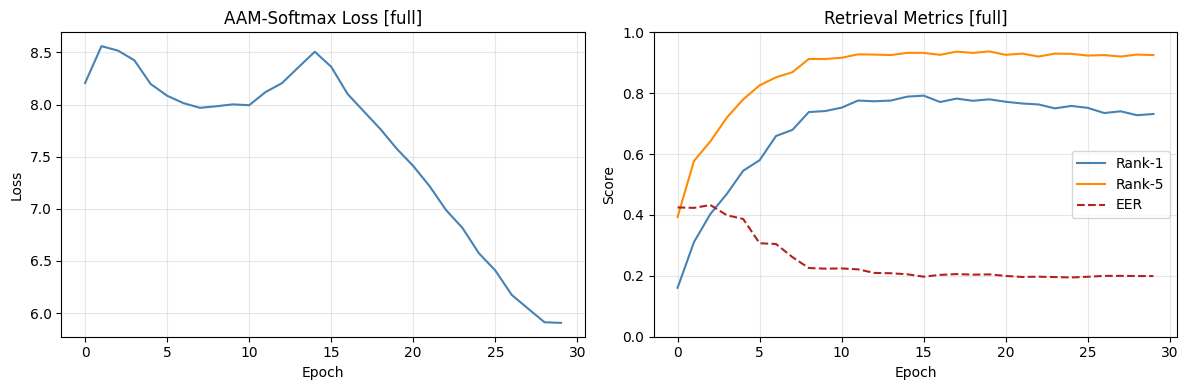

[full] Final — R@1=0.732  R@5=0.925  EER=0.199  mAP=0.332  | best EER=0.195


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["loss"], color="steelblue")
axes[0].set(xlabel="Epoch", ylabel="Loss", title=f"AAM-Softmax Loss [{MODE_TAG}]")
axes[0].grid(alpha=0.3)
axes[1].plot(history["rank1"], label="Rank-1", color="steelblue")
axes[1].plot(history["rank5"], label="Rank-5", color="darkorange")
axes[1].plot(history["eer"],   label="EER",    color="firebrick", linestyle="--")
axes[1].set(xlabel="Epoch", ylabel="Score", title=f"Retrieval Metrics [{MODE_TAG}]", ylim=(0, 1))
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, f"training_curves_{MODE_TAG}.png"), dpi=120)
plt.show()
print(f"[{MODE_TAG}] Final — R@1={history['rank1'][-1]:.3f}  R@5={history['rank5'][-1]:.3f}  "
      f"EER={history['eer'][-1]:.3f}  mAP={history['map'][-1]:.3f}  | best EER={min(history['eer']):.3f}")

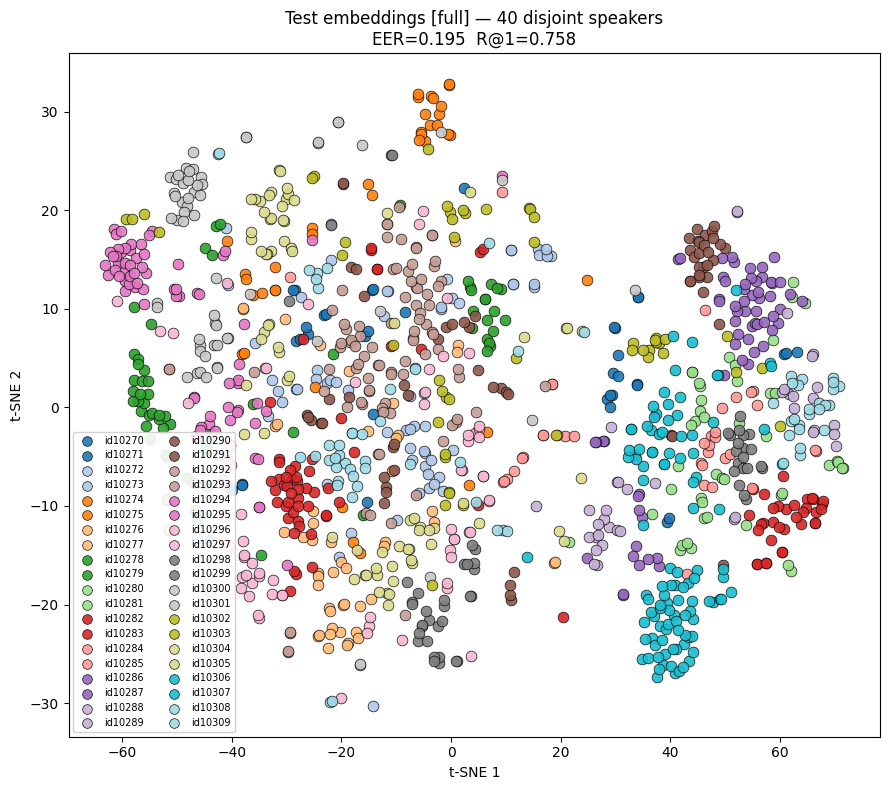

Saved → /kaggle/working/tsne_test_full.png


In [9]:
# t-SNE of the test embeddings, coloured by the (disjoint) test speaker.
import matplotlib as mpl

ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
core = model.module if isinstance(model, nn.DataParallel) else model
core.load_state_dict(ckpt["model"])

emb, lbl = encode_all(val_loader, model)               # val_loader is shuffle=False
assert np.array_equal(lbl.numpy(), y_val), "embedding order misaligned with labels"
emb_np = emb.numpy()

perp   = min(30, len(emb_np) - 1)
coords = TSNE(n_components=2, perplexity=perp, init="pca", random_state=42).fit_transform(emb_np)

pid_arr = np.asarray(pid_val)
cmap    = mpl.colormaps["tab20"].resampled(len(val_persons))
fig, ax = plt.subplots(figsize=(9, 8))
for i, person in enumerate(val_persons):
    m = pid_arr == person
    ax.scatter(coords[m, 0], coords[m, 1], color=cmap(i), s=60,
               edgecolors="black", linewidths=0.5, alpha=0.9, label=person)
ax.set(xlabel="t-SNE 1", ylabel="t-SNE 2",
       title=f"Test embeddings [{MODE_TAG}] — {len(val_persons)} disjoint speakers\n"
             f"EER={ckpt.get('eer', float('nan')):.3f}  R@1={ckpt.get('rank1', float('nan')):.3f}")
ax.legend(ncol=2, fontsize=7, markerscale=0.9, loc="best", framealpha=0.9)
plt.tight_layout()
out_path = os.path.join(WORK_DIR, f"tsne_test_{MODE_TAG}.png")
plt.savefig(out_path, dpi=120); plt.show()
print(f"Saved → {out_path}")